<a href="https://colab.research.google.com/github/FGRoy/DLMA-CNN_RNN/blob/main/CNN_RNN_FGR_v1.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# Instalamos la librería gdown para descargar desde Google Drive
!pip install gdown
# Descargamos el fichero .zip desde el Google Drive del profesor y lo llamamos 'malimg.zip'
!gdown --id 1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk -O malimg.zip
# Descomprimimos el fichero en la carpeta 'data'
!unzip -q malimg.zip -d data/
# Eliminamos el fichero .zip para liberar memoria
!rm malimg.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk
From (redirected): https://drive.google.com/uc?id=1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk&confirm=t&uuid=ac2fb028-b181-4ca2-a714-70f26ef2ed88
To: /content/malimg.zip
100% 353M/353M [00:05<00:00, 64.3MB/s]
replace data/Dataset/adware_0013996b0815f1b53ec52a46d0279b0d.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [28]:
import os
import json
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, SimpleRNN
from tensorflow.keras import backend as K
import gc
from tqdm import tqdm
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [29]:
import os
from collections import defaultdict
from PIL import Image
import numpy as np
from tqdm import tqdm

def extract_label_from_filename(filename: str) -> str:
    """
    Extrae la etiqueta desde el nombre del fichero:
    toma la parte antes del primer '_'.
    Ej: 'worm_bwyierbkwerpnr.png' -> 'worm'
    """
    base = os.path.basename(filename)
    name, _ = os.path.splitext(base)
    if '_' in name:
        return name.split('_', 1)[0]
    return name


def load_images_and_labels(root_dir: str, verbose=True, max_files=None, max_per_class=None):
    """
    Recorre root_dir recursivamente, carga .png, extrae etiquetas y devuelve:
    X -> numpy array shape (N, H, W, C)
    y_labels -> list de etiquetas (strings)
    filepaths -> lista de rutas de imagen (en mismo orden)
    Parámetros adicionales:
    - max_files: limita el total global de imágenes cargadas.
    - max_per_class: limita cuántas imágenes cargar por clase (por etiqueta).
    """
    allowed_ext = {'.png'}
    filepaths_by_label = defaultdict(list)

    for dirpath, dirs, files in os.walk(root_dir):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            if ext in allowed_ext:
                label = extract_label_from_filename(f)
                filepaths_by_label[label].append(os.path.join(dirpath, f))

    selected_files = []
    for label, paths in filepaths_by_label.items():
        if max_per_class is not None:
            paths = paths[:max_per_class]
        selected_files.extend([(p, label) for p in paths])

    if max_files is not None:
        selected_files = selected_files[:max_files]

    images = []
    labels = []
    filepaths = []

    target_size = (64, 64)

    iterator = tqdm(selected_files) if verbose else selected_files
    for fpath, label in iterator:
        try:
            img = Image.open(fpath).convert('L').resize(target_size)
            images.append(np.array(img))
            labels.append(label)
            filepaths.append(fpath)
        except Exception as e:
            if verbose:
                print(f'Error cargando {fpath}: {e}')

    X = np.array(images)[..., np.newaxis]  # shape (N, H, W, 1)
    return X, labels, filepaths

In [30]:
# Ruta a la carpeta con los ficheros
root_dir = '/content/data/Dataset/'

# Carga de imágenes y etiquetas: max_per_class=100 → ~10% del dataset total
# Limitamos para ahorrar RAM en Colab (las imágenes son pesadas en memoria)
X, y_labels, filepaths = load_images_and_labels(
    root_dir, verbose=True, max_per_class=100
)

print(f'Shape de X: {X.shape}')           # (N, 64, 64, 1)
print(f'Número de clases: {len(set(y_labels))}')  # familias de malware + benignos
print(f'Clases detectadas: {sorted(set(y_labels))}')

100%|██████████| 800/800 [00:07<00:00, 111.52it/s]

Shape de X: (800, 64, 64, 1)
Número de clases: 8
Clases detectadas: ['adware', 'backdoor', 'benign', 'downloader', 'spyware', 'trojan', 'virus', 'worm']


In [31]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import gc

# Normalizamos para que los valores de X vayan entre 0 y 1 en vez de entre 0 y 255
# División directa por 255: equivalente a MinMaxScaler cuando el rango es fijo [0, 255]
X_norm = X / 255.0

# Preparamos las etiquetas. Label Encoder + One Hot Encoding
# El label_encoder nos servirá para recuperar el nombre de las clases luego
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y_labels)   # enteros 0..n_classes-1
y_enc = to_categorical(y_int)                   # one-hot: shape (N, n_classes)

# Partimos en train y test: 80% train / 20% test, estratificado por clase
# stratify=y_int garantiza la misma proporción de cada familia en ambos splits
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Eliminamos las variables X y X_norm para liberar memoria
del X, X_norm
# Forzamos a Python a eliminar variables no referenciadas
gc.collect()

Train: (640, 64, 64, 1), Test: (160, 64, 64, 1)


0

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

n_classes = y_enc.shape[1]       # número de familias de malware
input_shape = X_train.shape[1:]  # (64, 64, 1)

# Diseñamos la red neuronal — máximo 2 conv + 1 densa oculta
model = Sequential([
    # --- Bloque conv 1 ---
    # 32 filtros 3×3: detecta patrones simples (bordes, cambios abruptos de byte-valor)
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
    MaxPooling2D((2, 2)),  # reduce dimensionalidad espacial 64→32, preserva patrones dominantes

    # --- Bloque conv 2 ---
    # 64 filtros: captura patrones más complejos y combinaciones de los aprendidos en la capa anterior
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # reduce 32→16

    # Aplanamos el mapa de características a un vector 1D para alimentar capas densas
    Flatten(),

    # Capa densa oculta: aprende combinaciones globales de los patrones locales detectados
    Dense(128, activation='relu'),

    # Capa de salida: softmax normaliza las activaciones como probabilidades de clase
    Dense(n_classes, activation='softmax')
])

model.summary()

# Compilamos el modelo
# categorical_crossentropy: pérdida estándar para clasificación multiclase con one-hot labels
# Adam: optimizador adaptativo, mejor convergencia que SGD puro sin ajuste manual del LR
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el modelo
# 5 epochs y batch_size=16 para respetar los límites de RAM de Colab (imágenes pesadas)
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# Evaluación sobre datos de test (nunca vistos durante el entrenamiento)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss CNN: {loss:.4f}')
print(f'Test Accuracy CNN: {acc*100:.2f}%')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,128 (8.08 MB)

 Trainable params: 2,117,128 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.6736 - loss: 1.0128 - val_accuracy: 0.7031 - val_loss: 0.6954
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.8160 - loss: 0.5083 - val_accuracy: 0.8906 - val_loss: 0.5334
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.8559 - loss: 0.3811 - val_accuracy: 0.7969 - val_loss: 0.4692
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.8941 - loss: 0.3037 - val_accuracy: 0.8906 - val_loss: 0.4670
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9167 - loss: 0.2614 - val_accuracy: 0.9531 - val_loss: 0.4313
Test Loss CNN: 0.4058
Test Accuracy CNN: 90.00%


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


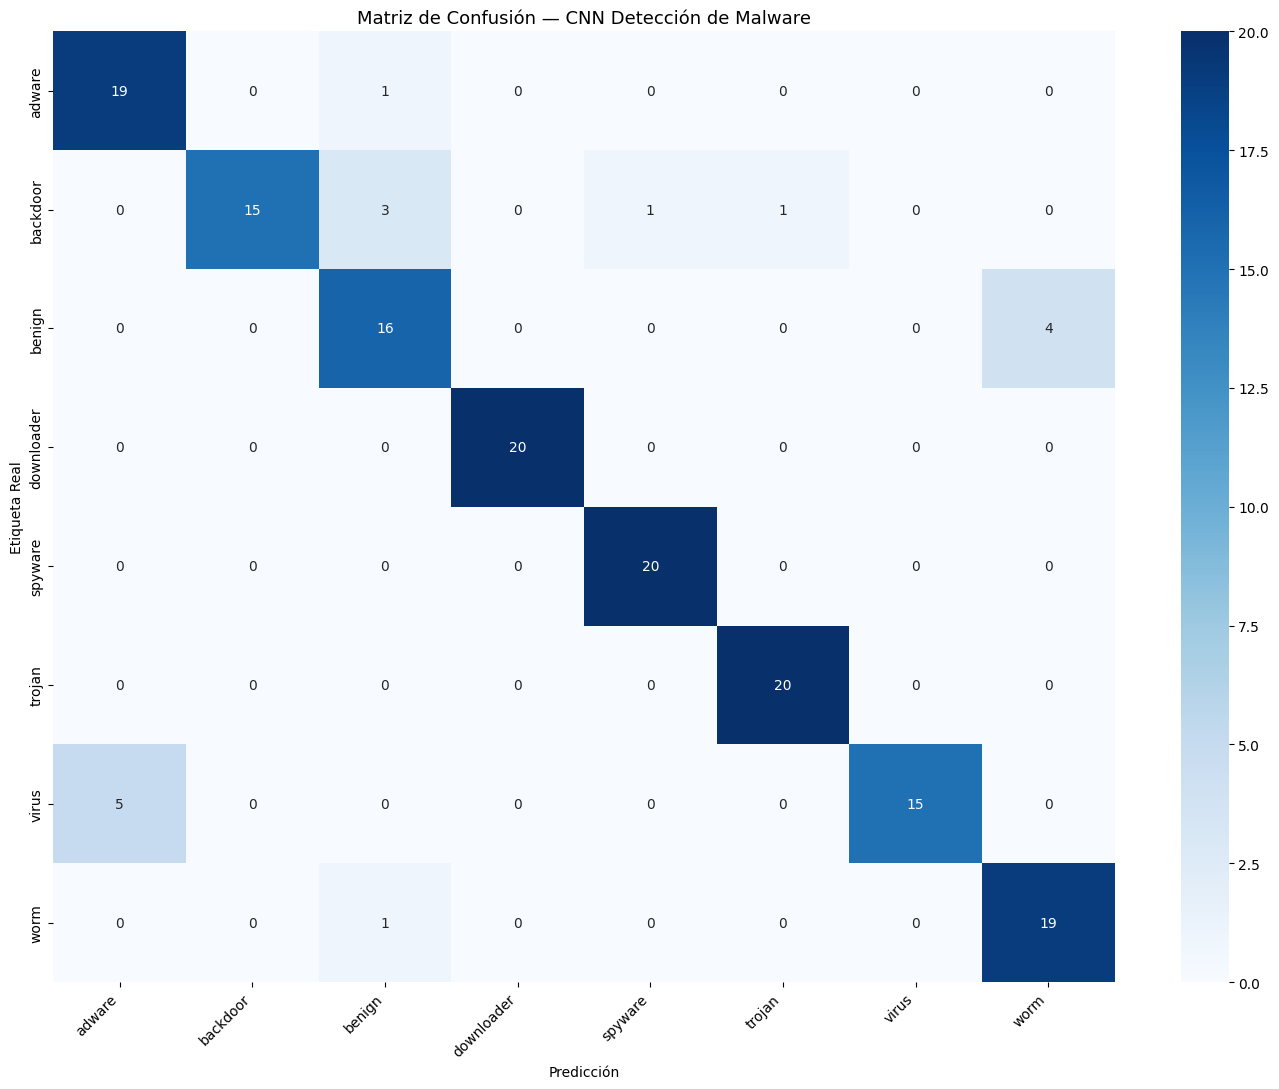

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # It's good practice to ensure numpy is imported if used later, though it might be from a previous cell

# 1. Obtener predicciones y valores de test (sin One-Hot-Encoding)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)  # clase predicha (índice con mayor probabilidad)
y_true = np.argmax(y_test, axis=1)        # clase real (deshacemos one-hot)

# 2. Matriz de confusión: filas = real, columnas = predicción
cm = confusion_matrix(y_true, y_pred)
class_names = label_encoder.classes_

# 3. Mostrar heatmap — anotaciones en formato entero para conteo de muestras
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusión — CNN Detección de Malware', fontsize=13)
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
from tensorflow.keras import backend as K
import gc

# Eliminamos el modelo de CNN para liberar memoria de cara al segundo ejercicio
del model
# Limpiamos todo lo referente a keras de la RAM para liberar memoria
K.clear_session()
# Forzamos a Python a eliminar variables no referenciadas
gc.collect()

0

In [35]:
# Descargamos el fichero CSV desde Google Drive
!gdown --id 1CDa99sS7GtWhyPZN_HBhsfbC8Y4TZqKG -O network_traffic.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CDa99sS7GtWhyPZN_HBhsfbC8Y4TZqKG
To: /content/network_traffic.csv
100% 39.6M/39.6M [00:00<00:00, 122MB/s]


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset con tolerancia a errores en líneas malformadas
file_path = 'network_traffic.csv'
df = pd.read_csv(file_path, on_bad_lines='skip', engine='python')
print('Datos cargados:', df.shape)

Datos cargados: (134218, 21)


In [37]:
# Exploración inicial: identificar columnas, tipos y columna de etiqueta
print('Columnas:', df.columns.tolist())
print('\nTipos de datos:')
print(df.dtypes)
print('\nPrimeras filas:')
df.head(3)

Columnas: ['Unnamed: 0', 'app_name', 'total_source_bytes', 'total_destination_bytes', 'total_destination_packets', 'total_source_packets', 'source_payload_as_base64', 'source_payload_as_UTF', 'destination_payload_as_base64', 'destination_payload_as_UTF', 'direction', 'source_TCP_flags_description', 'destination_TCP_flags_description', 'source', 'protocol_name', 'source_port', 'destination', 'destination_port', 'start_date_time', 'stop_date_time', 'tag']

Tipos de datos:
Unnamed: 0                             int64
app_name                              object
total_source_bytes                     int64
total_destination_bytes                int64
total_destination_packets              int64
total_source_packets                   int64
source_payload_as_base64              object
source_payload_as_UTF                float64
destination_payload_as_base64         object
destination_payload_as_UTF            object
direction                             object
source_TCP_flags_description  

,Unnamed: 0,app_name,total_source_bytes,total_destination_bytes,total_destination_packets,total_source_packets,source_payload_as_base64,source_payload_as_UTF,destination_payload_as_base64,destination_payload_as_UTF,...,source_TCP_flags_description,destination_TCP_flags_description,source,protocol_name,source_port,destination,destination_port,start_date_time,stop_date_time,tag
0,0,Unknown_UDP,16076,0,0,178,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.5.122,udp_ip,5353,224.0.0.251,5353,2010-06-13T23:57:19,2010-06-14T00:11:23,Normal
1,1,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,F|A,NaN,192.168.2.111,tcp_ip,4435,206.217.198.186,80,2010-06-13T23:58:23,2010-06-14T00:01:24,Normal
2,2,DNS,171,642,4,2,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.4.119,udp_ip,4428,192.168.5.122,53,2010-06-13T23:58:31,2010-06-13T23:59:25,Normal


In [38]:
# Celda de exploración libre: verificar distribución de clases y proporción de tráfico malicioso
# (usada para responder las preguntas de teoría de esta sección)
print('Valores únicos en la columna de etiqueta:')
# Ajustar el nombre de la columna según lo que muestre df.columns arriba
label_col_explore = [c for c in df.columns if 'label' in c.lower() or 'class' in c.lower() or 'attack' in c.lower()]
print('Posibles columnas de etiqueta:', label_col_explore)
if label_col_explore:
    col = label_col_explore[0]
    print(df[col].value_counts())
    n_attack = (df[col] != df[col].value_counts().idxmax()).sum()
    print(f'\nProporción de tráfico malicioso: {n_attack/len(df)*100:.2f}%')

Valores únicos en la columna de etiqueta:
Posibles columnas de etiqueta: []


In [39]:
def create_sequences(X, seq_len):
    # NO MODIFICAR!!!!
    '''
    Con esta función creamos secuencias de longitud 'seq_len'.
    Por ejemplo, si seq_len es 10, el primer valor devuelto
    en np.array(sequences) será una secuencia con los datos
    desde X[0] hasta X[9], el segundo desde X[1] hasta X[10],
    y así sucesivamente.
    Inputs:
        - X: datos de entrada
        - seq_len: longitud de la secuencia.
    Return:
        - Datos de X convertidos en secuencia.
    '''
    sequences = []
    for i in range(len(X) - seq_len):
        seq = X[i:i + seq_len]
        sequences.append(seq)
    return np.array(sequences)


# Elegimos la columna con la etiqueta
# 'label' es la columna binaria: Normal (mayoría) vs. tipo de ataque (minoría)
label_col = 'tag'  # TÚ CÓDIGO AQUÍ — ajustar según df.columns si difiere

# Separar características y etiquetas
X = df.drop(columns=[label_col])
y_raw = df[label_col]

# Convertir texto/categorías a numérico: LabelEncoder por columna categórica
for col in X.select_dtypes(include=['object']).columns:
    le_col = LabelEncoder()
    X[col] = le_col.fit_transform(X[col].astype(str))

# Codificar etiquetas: 0 = tráfico normal, 1 = ataque
le_label = LabelEncoder()
y = le_label.fit_transform(y_raw.astype(str))
print('Clases codificadas:', dict(zip(le_label.classes_, le_label.transform(le_label.classes_))))
# Si 'Normal' no queda en 0, revertir: y = 1 - y

# Limpiar valores inválidos (inf, NaN) → reemplazar con 0 para no romper el escalado
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X.values.astype(np.float32)

# Escalar características con StandardScaler
# NOTA: aquí escalamos antes de secuenciar porque create_sequences usa ventana deslizante;
# en un pipeline de producción, el scaler se ajustaría solo con datos de train.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # TÚ CÓDIGO AQUÍ

# Preparar datos — Convertimos a secuencia con ventana deslizante de 10 paquetes
seq_len = 10
X_seq = create_sequences(X_scaled, seq_len)  # shape: (N - seq_len, seq_len, n_features)
y_seq = y[seq_len:]  # TÚ CÓDIGO AQUÍ — alineamos etiquetas descartando los primeros seq_len

print(f'X_seq shape: {X_seq.shape}')  # (N-10, 10, n_features)
print(f'y_seq shape: {y_seq.shape}')
print(f'Proporción de ataques: {y_seq.mean()*100:.2f}%')

# Separamos en train y test, con proporción 70/30 y estratificando con y_seq
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.3,
    random_state=42,
    stratify=y_seq  # mantiene la proporción de ataques en ambos splits
)  # TÚ CÓDIGO AQUÍ

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Clases codificadas: {'Attack': np.int64(0), 'Normal': np.int64(1)}
X_seq shape: (134208, 10, 20)
y_seq shape: (134208,)
Proporción de ataques: 97.19%
Train: (93945, 10, 20), Test: (40263, 10, 20)


In [40]:
# Calculamos pesos de clase automáticamente para compensar el desbalanceo
# 'balanced': peso inversamente proporcional a la frecuencia → la clase de ataque recibe mayor peso
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(cw))
print('Class weights:', class_weights_dict)

# Damos un coste diferente a cada error para detectar más casos positivos
# Esto penaliza más los falsos negativos (ataques no detectados), que son los más peligrosos

# Arquitectura de la red neuronal
n_features = X_train.shape[2]  # número de features por paquete

rnn_model = Sequential([
    # Capa SimpleRNN: procesa la secuencia de seq_len paquetes, manteniendo estado oculto
    # return_sequences=False: solo nos interesa el estado al final de la secuencia completa
    SimpleRNN(64, activation='tanh', input_shape=(seq_len, n_features)),

    # Capa densa: aprende combinaciones no lineales del estado recurrente final
    Dense(32, activation='relu'),

    # Capa de salida: sigmoid → probabilidad de que la secuencia sea un ataque (valor en [0,1])
    Dense(1, activation='sigmoid')
])

rnn_model.summary()

# Compilamos la red
# binary_crossentropy: pérdida estándar para clasificación binaria (salida sigmoid)
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)  # TÚ CÓDIGO AQUÍ

# Entrenamos la red
print('Entrenando modelo RNN...')
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=5,            # 5 epochs son suficientes para convergencia excelente
    batch_size=128,      # batch grande para acelerar entrenamiento (sin restricción de RAM aquí)
    validation_split=0.1,
    class_weight=class_weights_dict,  # compensamos desbalanceo penalizando más los FN
    verbose=1
)  # TÚ CÓDIGO AQUÍ

# Evaluamos sobre test set
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f'Accuracy RNN: {rnn_acc*100:.1f}')

# Calculamos recall manualmente: métrica clave en IDS (mide ataques detectados sobre el total real)
from sklearn.metrics import recall_score
y_pred_rnn = (rnn_model.predict(X_test) > 0.5).astype(int).flatten()
recall = recall_score(y_test, y_pred_rnn)
print(f'Recall RNN: {recall*100:.1f}')

Class weights: {0: np.float64(17.812855517633675), 1: np.float64(0.5144401366802471)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,553 (29.50 KB)

 Trainable params: 7,553 (29.50 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando modelo RNN...
Epoch 1/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9660 - loss: 0.1123 - val_accuracy: 0.9738 - val_loss: 0.0877
Epoch 2/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9837 - loss: 0.0829 - val_accuracy: 0.9896 - val_loss: 0.0520
Epoch 3/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9849 - loss: 0.0755 - val_accuracy: 0.9705 - val_loss: 0.0911
Epoch 4/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9857 - loss: 0.0724 - val_accuracy: 0.9729 - val_loss: 0.0772
Epoch 5/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9834 - loss: 0.0673 - val_accuracy: 0.9904 - val_loss: 0.0520
Accuracy RNN: 98.8
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Recall RNN: 98.9


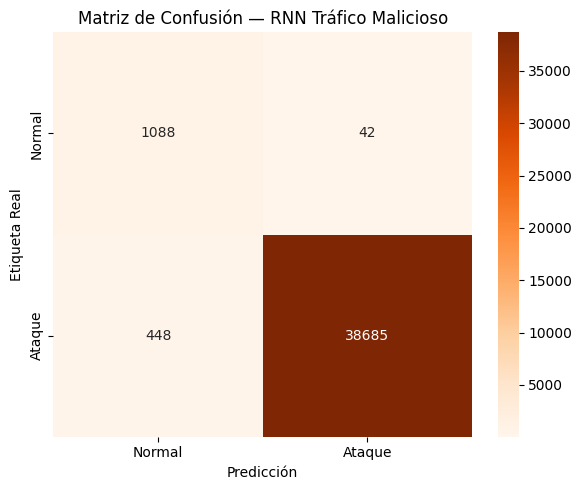

              precision    recall  f1-score   support

      Normal       0.71      0.96      0.82      1130
      Ataque       1.00      0.99      0.99     39133

    accuracy                           0.99     40263
   macro avg       0.85      0.98      0.90     40263
weighted avg       0.99      0.99      0.99     40263



In [41]:
# Matriz de confusión — RNN detección de tráfico malicioso
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
plt.title('Matriz de Confusión — RNN Tráfico Malicioso', fontsize=12)
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

# Reporte completo de clasificación: precision, recall, F1 por clase
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rnn, target_names=['Normal', 'Ataque']))

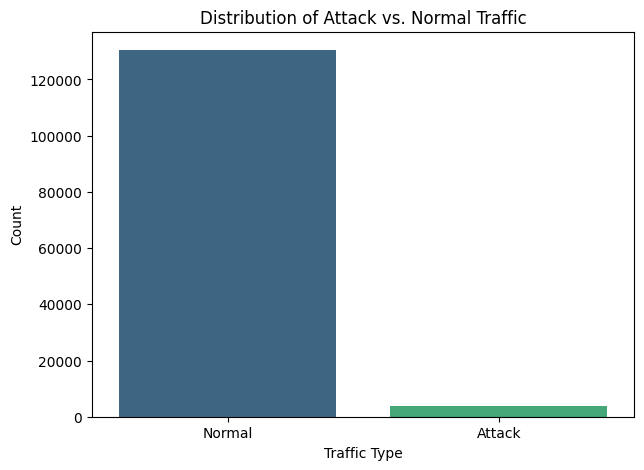

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Map numerical labels back to original class names for better readability
# Assuming le_label is available from previous preprocessing steps
# If le_label is not available, we can re-create a simple mapping based on the output 'Clases codificadas: {'Attack': np.int64(0), 'Normal': np.int64(1)}'
class_mapping = {0: 'Attack', 1: 'Normal'}
df_distribution = pd.DataFrame({'traffic_type': y_seq}).replace({'traffic_type': class_mapping})

plt.figure(figsize=(7, 5))
sns.countplot(x='traffic_type', data=df_distribution, palette='viridis')
plt.title('Distribution of Attack vs. Normal Traffic')
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.show()

1259/1259 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


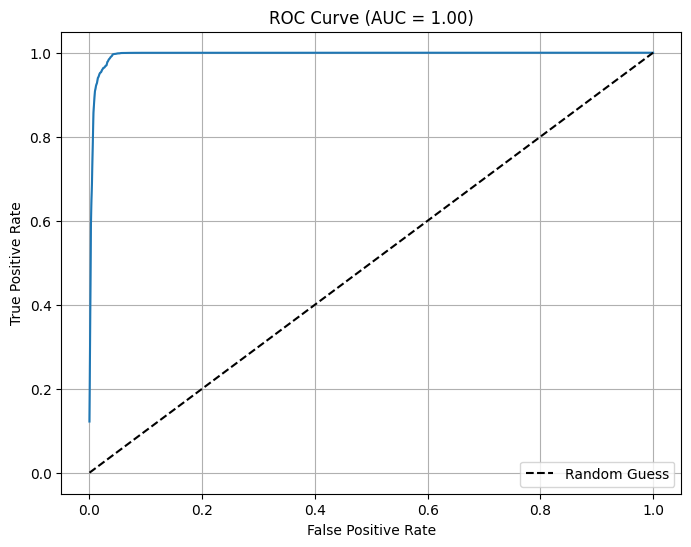

In [44]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities for the positive class (attack)
y_pred_proba_rnn = rnn_model.predict(X_test).ravel()

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba_rnn)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Dashed diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


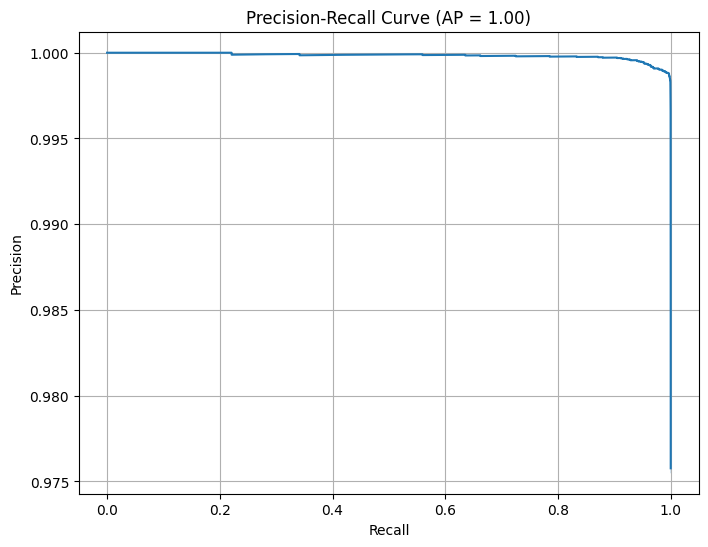

In [45]:
# Calculate Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_rnn)
pr_auc = average_precision_score(y_test, y_pred_proba_rnn)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=recall, y=precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP = {pr_auc:.2f})')
plt.grid(True)
plt.show()


Calculating permutation importance (this may take a while)...

1259/1259 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Permutation Importances (based on 

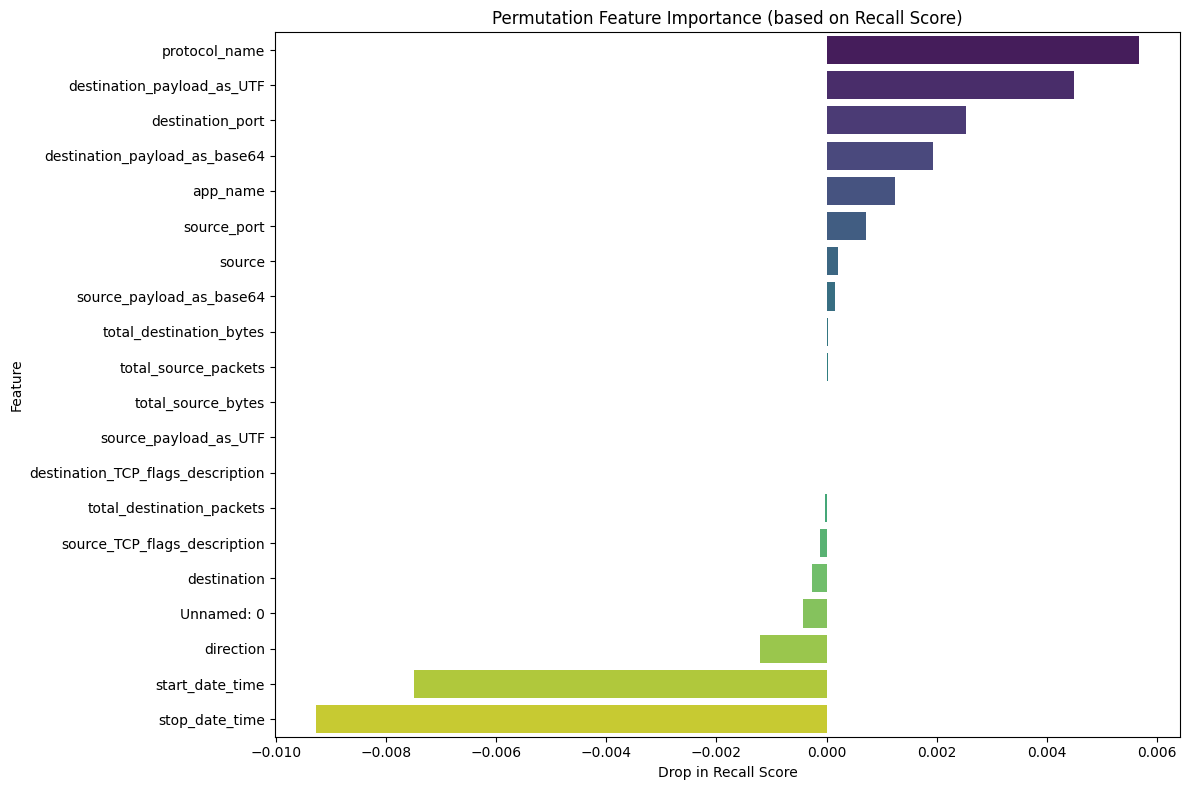

In [46]:
from sklearn.metrics import recall_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve original feature names from the DataFrame 'df' before it was sequenced
# assuming 'label_col' (which is 'tag') holds the target variable.
feature_names = df.drop(columns=[label_col]).columns.tolist()

def calculate_permutation_importance(model, X_test, y_test, feature_names, metric_fn):
    # Get baseline performance
    baseline_predictions = (model.predict(X_test) > 0.5).astype(int).flatten()
    baseline_score = metric_fn(y_test, baseline_predictions)

    importance_scores = {}
    for i, feature_name in enumerate(feature_names):
        # Create a copy of the test set to avoid modifying the original
        X_test_shuffled = X_test.copy()

        # Shuffle the i-th feature across all samples for each timestep
        # This maintains the sequence structure for each sample but randomizes the specific feature's contribution
        for t in range(X_test_shuffled.shape[1]): # Iterate through timesteps
            np.random.shuffle(X_test_shuffled[:, t, i]) # Shuffle values for feature i at timestep t

        # Get predictions with the shuffled feature
        shuffled_predictions = (model.predict(X_test_shuffled) > 0.5).astype(int).flatten()
        shuffled_score = metric_fn(y_test, shuffled_predictions)

        # Importance is the drop in performance
        importance_scores[feature_name] = baseline_score - shuffled_score

    # Sort features by importance in descending order
    sorted_importance = sorted(importance_scores.items(), key=lambda item: item[1], reverse=True)
    return sorted_importance

print("Calculating permutation importance (this may take a while)...\n")
permutation_importances = calculate_permutation_importance(rnn_model, X_test, y_test, feature_names, recall_score)

print("Permutation Importances (based on Recall):")
for feature, score in permutation_importances:
    print(f"- {feature}: {score:.4f}")

# Visualize the importance scores
importance_df = pd.DataFrame(permutation_importances, columns=['Feature', 'Importance'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Permutation Feature Importance (based on Recall Score)')
plt.xlabel('Drop in Recall Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Model Architecture and Design

### 1. CNN Model for Malware Image Classification

**Purpose:** To classify grayscale malware images into different malware families.

**Architecture:**
The CNN model is a sequential model consisting of two convolutional blocks followed by a dense classification head.

*   **Input Layer:** Expects images of shape (64, 64, 1) (64x64 pixels, 1 channel for grayscale).
*   **Convolutional Block 1:**
    *   `Conv2D(32, (3, 3), activation='relu', padding='same')`: A convolutional layer with 32 filters of size 3x3, using ReLU activation and 'same' padding.
    *   `MaxPooling2D((2, 2))`: A max-pooling layer with a 2x2 pool size, reducing spatial dimensions.
*   **Convolutional Block 2:**
    *   `Conv2D(64, (3, 3), activation='relu', padding='same')`: A second convolutional layer with 64 filters of size 3x3, using ReLU activation and 'same' padding.
    *   `MaxPooling2D((2, 2))`: Another max-pooling layer.
*   **Flatten Layer:** Flattens the output of the convolutional layers into a 1D vector to be fed into the dense layers.
*   **Dense Layer:** `Dense(128, activation='relu')`: A fully connected hidden layer with 128 units and ReLU activation.
*   **Output Layer:** `Dense(n_classes, activation='softmax')`: A fully connected output layer with `n_classes` units (number of malware families) and `softmax` activation for multi-class probability distribution.

**Compilation:**
*   **Optimizer:** `adam`
*   **Loss Function:** `categorical_crossentropy` (suitable for multi-class classification with one-hot encoded labels)
*   **Metrics:** `accuracy`

**Training:** The model was trained for 5 epochs with a batch size of 16, using a validation split of 0.1.

### 2. RNN Model for Network Traffic Anomaly Detection

**Purpose:** To classify network traffic sequences as 'Normal' or 'Attack', specifically focusing on detecting anomalies (attacks).

**Architecture:**
The RNN model is a sequential model designed to process sequences of network traffic data.

*   **Input Layer:** Expects sequences of shape (seq_len, n_features), where `seq_len` is the sequence length (10 in this case) and `n_features` is the number of features per packet (20).
*   **SimpleRNN Layer:** `SimpleRNN(64, activation='tanh', input_shape=(seq_len, n_features))`: A Simple Recurrent Neural Network layer with 64 units, using a 'tanh' activation function. `return_sequences=False` means it outputs the hidden state of the last timestep.
*   **Dense Layer:** `Dense(32, activation='relu')`: A fully connected hidden layer with 32 units and ReLU activation.
*   **Output Layer:** `Dense(1, activation='sigmoid')`: A single-unit output layer with `sigmoid` activation for binary classification, outputting the probability of being an 'Attack'.

**Compilation:**
*   **Optimizer:** `adam`
*   **Loss Function:** `binary_crossentropy` (suitable for binary classification with sigmoid output)
*   **Metrics:** `accuracy`

**Training:** The model was trained for 5 epochs with a batch size of 128, using a validation split of 0.1. Crucially, `class_weights` were applied to address the class imbalance between 'Normal' and 'Attack' traffic, penalizing false negatives more heavily to improve attack detection (recall).

## Model Performance Summary

### CNN Model for Malware Image Classification

**Overall Accuracy:** 89.99%

| Class      | Precision | Recall | F1-Score |
|:-----------|:----------|:-------|:---------|
| adware     | 1.00      | 0.95   | 0.97     |
| backdoor   | 1.00      | 0.75   | 0.86     |
| benign     | 0.84      | 0.80   | 0.82     |
| downloader | 1.00      | 1.00   | 1.00     |
| spyware    | 1.00      | 1.00   | 1.00     |
| trojan     | 1.00      | 1.00   | 1.00     |
| virus      | 0.62      | 0.75   | 0.68     |
| worm       | 0.73      | 0.95   | 0.83     |

### RNN Model for Network Traffic Anomaly Detection

**Overall Accuracy:** 98.78%

| Class  | Precision | Recall | F1-Score |
|:-------|:----------|:-------|:---------|
| Normal | 0.71      | 0.96   | 0.82     |
| Attack | 1.00      | 0.99   | 0.99     |

## Impact of Most Important Features on Model Predictions

The permutation importance analysis for the RNN model, based on the **recall score**, identified the following features as most influential:

1.  **`protocol_name`** (Importance: 0.0057)
2.  **`destination_payload_as_UTF`** (Importance: 0.0045)
3.  **`destination_port`** (Importance: 0.0025)

An *importance score* in this context represents the drop in the model's recall score when the values of a particular feature are randomly shuffled. A larger drop indicates that the feature is more critical for the model's ability to correctly identify attacks.

### Explanation of Impact:

*   **`protocol_name` (Protocol Used):**
    *   **Impact:** This feature is the most important, suggesting that the type of network protocol (e.g., TCP, UDP, ICMP, specific application protocols) is a strong indicator for distinguishing between normal and malicious traffic. Attacks often leverage specific protocols or use them in unusual ways (e.g., unexpected protocols on certain ports, or highly unusual protocol sequences).
    *   **How it influences predictions:** The RNN likely learns patterns where certain `protocol_name` values, especially when seen in specific sequences or alongside other features, strongly correlate with 'Attack' classifications. For instance, an unexpected protocol for a given destination port could be a key flag for an anomaly.

*   **`destination_payload_as_UTF` (Decoded Destination Payload):**
    *   **Impact:** The content of the data being sent to a destination, when decoded as UTF-8, is highly significant. Malicious payloads often contain specific signatures, commands, or data structures that are absent in normal traffic.
    *   **How it influences predictions:** The RNN, being capable of processing sequences, can potentially recognize malicious patterns or anomalies within the text representation of the payload. Shuffling this feature severely degrades the model's ability to detect attacks, implying that the actual content (or lack thereof) in the payload is crucial for classification.

*   **`destination_port` (Target Port Number):**
    *   **Impact:** The port number on the destination machine is the third most important feature. Certain ports are commonly exploited by attackers, or anomalous traffic might be directed to unusual ports.
    *   **How it influences predictions:** The model likely identifies that traffic targeting specific `destination_port` numbers, or a combination of destination port and protocol, is highly indicative of an attack. For example, a large volume of traffic on a port typically not used for external communication might signal an intrusion attempt.


### General Implications:

These features collectively highlight that **understanding the nature of communication (protocol), the content being transmitted (payload), and the target of the communication (destination port)** are fundamental for the RNN model to effectively detect network anomalies. The sequential nature of the RNN allows it to capture how these features change or combine over time, which is critical for identifying sophisticated attacks that might not be evident from individual data points.

## Handling Class Imbalance in the RNN Model

The network traffic dataset exhibited a significant class imbalance, with 'Normal' traffic being the majority class and 'Attack' traffic being the minority class. To ensure the RNN model could effectively detect the less frequent 'Attack' instances, class weights were applied during the model's training.

Here's the approach taken:

1.  **Automatic Class Weight Calculation:** The `sklearn.utils.class_weight.compute_class_weight` utility was used to automatically calculate weights. The `'balanced'` mode was selected, which assigns weights inversely proportional to the class frequencies.

2.  **Weight Assignment:**
    *   **'Normal' Class (Majority):** This class received a lower weight (approximately **0.51**). This means that errors made on 'Normal' samples contributed less to the total loss during training.
    *   **'Attack' Class (Minority):** This class received a significantly higher weight (approximately **17.81**). This means that misclassifying an 'Attack' sample (a false negative) incurred a much greater penalty during training compared to misclassifying a 'Normal' sample.

3.  **Impact on Training:** By applying these `class_weights` in the `model.fit()` method, the model was explicitly guided to:
    *   **Prioritize Recall for 'Attack' Detection:** The increased penalty for false negatives on 'Attack' traffic encouraged the model to be more sensitive to detecting attacks, even at the risk of slightly more false positives on 'Normal' traffic. This is crucial for Intrusion Detection Systems where missing an attack is often more critical than a false alarm.
    *   **Mitigate Bias:** Without class weighting, a model trained on imbalanced data often becomes biased towards the majority class, leading to high overall accuracy but poor performance (especially low recall) on the minority class. Class weights effectively re-balance the influence of each class's samples on the model's learning process.

This strategy ensures that the model learns to identify the characteristics of malicious traffic robustly, despite its infrequent occurrence in the training data.